# Stock market chart pattern recognition using deep learning 


In [174]:
pip install settrade_v2
pip install cassandra-driver
pip install schedule

SyntaxError: invalid syntax (749739844.py, line 1)

In [182]:
from settrade_v2 import Investor
import pandas as pd
import cassandra
import re
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from cassandra.cluster import Cluster
import requests
from fuzzywuzzy import fuzz
from collections import defaultdict
from fuzzywuzzy import process
from nltk.tokenize import word_tokenize
import requests
import schedule
import time
from cassandra.cluster import Cluster
from datetime import datetime
import yfinance as yf
import mplfinance as mpf

# 1.Settrade APi

In [183]:
# กำหนดค่า API Credentials
investor = Investor(
    app_id="a0iOat7M4FrOrGxS",       
    app_secret="AJcSTgM8JP+N2Uzi6eBGFxnv7i0T6RPzTX+6FiTgfgnp",  
    broker_id="SANDBOX",  
    app_code="SANDBOX"
    
)
market = investor.MarketData()


# 2. Connect cassandra ,Collect data and insert data

In [184]:
cluster = Cluster(['127.0.0.1'])  # or 'localhost'
session = cluster.connect()

In [206]:
# กรณี Investor
market = investor.MarketData()


df = market.get_candlestick(
    symbol="TRUBB",
    interval="1d",
    limit=1,
    normalized=True,
)

print(df)
print(type(df))

{'lastSequence': 0, 'time': [1743526800], 'open': [0.7], 'high': [0.71], 'low': [0.69], 'close': [0.69], 'volume': [460710], 'value': [322114.24]}
<class 'dict'>


In [207]:
# 👉 เลือกใช้ Keyspace
session.set_keyspace('stock_data')

# 👉 ตรวจสอบและสร้างตาราง (ถ้ายังไม่มี)
session.execute("""
    CREATE TABLE IF NOT EXISTS candlestick_data (
        symbol TEXT,
        time TIMESTAMP PRIMARY KEY,
        open_price FLOAT,
        high_price FLOAT,
        low_price FLOAT,
        close_price FLOAT,
        volume INT,
        value FLOAT
    )
""")
print("✅ Keyspace และ Table พร้อมใช้งาน!")

✅ Keyspace และ Table พร้อมใช้งาน!


In [208]:
# 👉 ฟังก์ชันดึงข้อมูลหุ้น
def fetch_and_store_stock(symbol="TRUBB", interval="1d", limit=10):
    res = market.get_candlestick(symbol=symbol, interval=interval, limit=limit, normalized=True)

    if not res:
        print(f"⚠️ ไม่พบข้อมูลสำหรับ {symbol}")
        return

    for i in range(len(res["time"])):
        timestamp = datetime.fromtimestamp(res["time"][i])  
        open_price = res["open"][i]
        high_price = res["high"][i]
        low_price = res["low"][i]
        close_price = res["close"][i]
        volume = res["volume"][i]
        value = res["value"][i]

        session.execute("""
            INSERT INTO candlestick_data (symbol, time, open_price, high_price, low_price, close_price, volume, value)
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
        """, (symbol, timestamp, open_price, high_price, low_price, close_price, volume, value))

    print(f"✅ เพิ่มข้อมูล {len(res['time'])} รายการของหุ้น {symbol} สำเร็จ!")

# 👉 ทดสอบดึงข้อมูลหุ้น TRUBB
fetch_and_store_stock(symbol="TRUBB", interval="1d", limit=10)

✅ เพิ่มข้อมูล 10 รายการของหุ้น TRUBB สำเร็จ!


In [209]:
def insert_candlestick_data(symbol, interval="1d", limit=10):
    try:
        # 👉 ดึงข้อมูลจาก Settrade API
        res = market.get_candlestick(symbol=symbol, interval=interval, limit=limit, normalized=True)

        if not res:
            print(f"⚠️ ไม่พบข้อมูลสำหรับ {symbol}")
            return

        # 👉 เชื่อมต่อกับ Cassandra
        cluster = Cluster(['127.0.0.1'])  
        session = cluster.connect()
        session.set_keyspace('stock_data')

        # 👉 บันทึกข้อมูลลงฐานข้อมูล
        for i in range(len(res["time"])):
            timestamp = datetime.fromtimestamp(res["time"][i])
            open_price = res["open"][i]
            high_price = res["high"][i]
            low_price = res["low"][i]
            close_price = res["close"][i]
            volume = res["volume"][i]
            value = res["value"][i]

            session.execute("""
                INSERT INTO candlestick_data (symbol, time, open_price, high_price, low_price, close_price, volume, value)
                VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
            """, (symbol, timestamp, open_price, high_price, low_price, close_price, volume, value))

        print(f"✅ เพิ่มข้อมูล {len(res['time'])} รายการของหุ้น {symbol} สำเร็จ!")

    except Exception as e:
        print(f"❌ เกิดข้อผิดพลาดในการดึงข้อมูลของหุ้น {symbol}: {e}")


In [210]:
# 🔄 รายชื่อหุ้นที่ต้องการทดสอบ
symbols = ["TRUBB"]
intervals = ["1d"]

# ✅ วนลูปดึงข้อมูลหุ้นตามช่วงเวลาที่กำหนด
for symbol in symbols:
    for interval in intervals:
        print(f"🔄 กำลังดึงข้อมูลสำหรับ {symbol} (Interval: {interval})...")
        insert_candlestick_data(symbol, interval=interval, limit=10)
        time.sleep(2)  # ⏳ ลด API Rate Limit


🔄 กำลังดึงข้อมูลสำหรับ TRUBB (Interval: 1d)...
✅ เพิ่มข้อมูล 10 รายการของหุ้น TRUBB สำเร็จ!


In [211]:
# ✅ ดึงข้อมูลจาก Cassandra
symbol = "TRUBB"  # เปลี่ยนเป็นหุ้นที่ต้องการ
query = f"SELECT time, open_price, high_price, low_price, close_price, volume FROM candlestick_data WHERE symbol = '{symbol}' ALLOW FILTERING;"
rows = session.execute(query)

# ✅ สร้าง DataFrame
data = []
for row in rows:
    data.append({
        "time": row.time,
        "open": row.open_price,
        "high": row.high_price,
        "low": row.low_price,
        "close": row.close_price,
        "volume": row.volume
    })

df = pd.DataFrame(data)
print(df)

          time  open  high   low  close   volume
0   2024-12-19  1.00  1.01  1.00   1.01   156700
1   2024-10-29  1.10  1.12  1.09   1.11  2605101
2   2024-10-04  1.17  1.19  1.16   1.16  4152902
3   2024-11-06  1.09  1.12  1.08   1.10  2581302
4   2024-11-07  1.10  1.13  1.09   1.09  2029802
..         ...   ...   ...   ...    ...      ...
96  2024-10-28  1.11  1.12  1.09   1.09  3713760
97  2024-10-10  1.19  1.19  1.17   1.17  2151735
98  2024-12-25  1.01  1.06  1.01   1.04  3213100
99  2025-03-18  0.70  0.71  0.68   0.69   257306
100 2024-12-17  1.05  1.07  1.01   1.01  1101651

[101 rows x 6 columns]


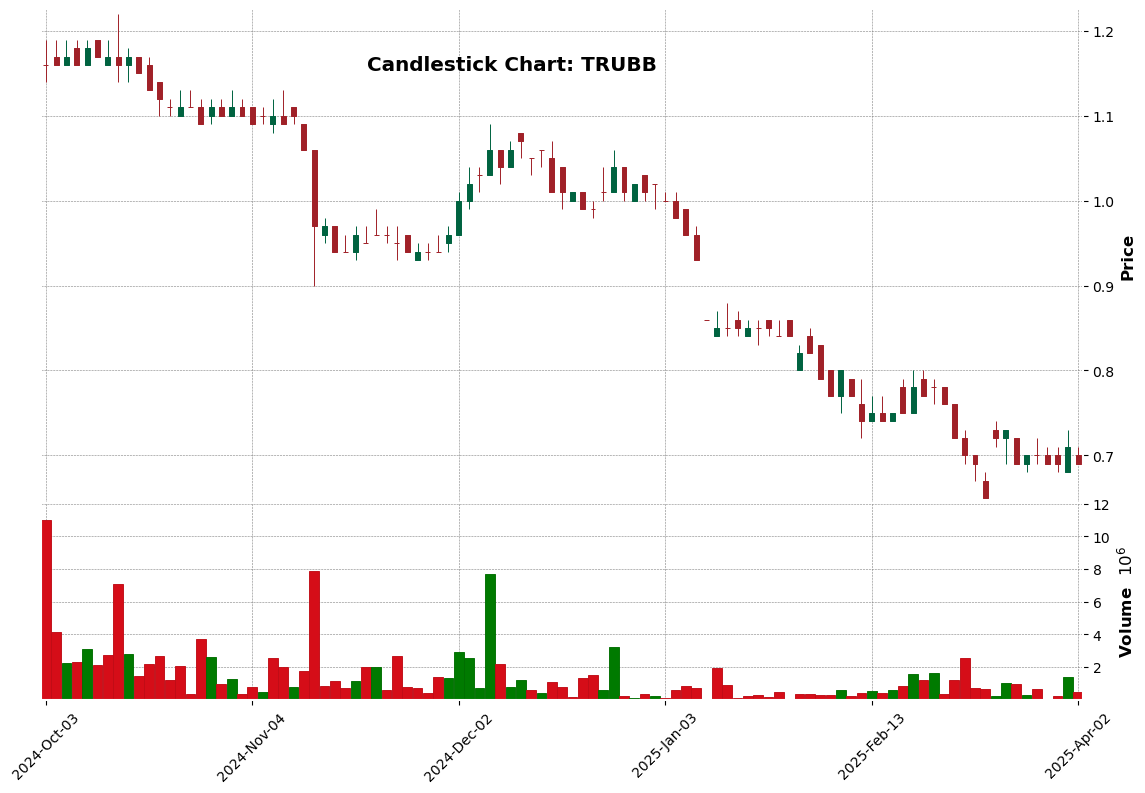

In [212]:
# ✅ จัดรูปแบบ DataFrame
df['time'] = pd.to_datetime(df['time'])  # แปลงเป็น datetime
df.set_index('time', inplace=True)  # ตั้งค่า index เป็น time
df.sort_index(inplace=True)  # เรียงลำดับตามเวลา

# ✅ ปรับปรุงกราฟแท่งเทียน (Candlestick Chart) ให้ดูง่ายขึ้น
custom_style = mpf.make_mpf_style(base_mpf_style='charles', gridcolor='gray', gridstyle='--')

mpf.plot(
    df,
    type='candle',
    style=custom_style,
    title=f"Candlestick Chart: {symbol}",
    ylabel='Price',
    volume=True,  # เพิ่มแถบ Volume
    figsize=(12, 8),  # เพิ่มขนาดกราฟ
    tight_layout=True  # ลดช่องว่างรอบกราฟ
)

plt.show()

In [213]:
# ✅ คำนวณ Feature Set สำหรับการวิเคราะห์
df['SMA_10'] = df['close'].rolling(window=10).mean()  # ค่าเฉลี่ยเคลื่อนที่ 10 วัน
df['SMA_50'] = df['close'].rolling(window=50).mean()  # ค่าเฉลี่ยเคลื่อนที่ 50 วัน
df['Return'] = df['close'].pct_change()  # อัตราการเปลี่ยนแปลงรายวัน (% Change)

# ✅ คำนวณ Bollinger Bands
df['std_20'] = df['close'].rolling(window=20).std()
df['Upper_Band'] = df['SMA_10'] + (df['std_20'] * 2)
df['Lower_Band'] = df['SMA_10'] - (df['std_20'] * 2)

# ✅ คำนวณ RSI (Relative Strength Index)
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['close'])

# ✅ แสดง Feature Set
print(df[['close', 'SMA_10', 'SMA_50', 'Upper_Band', 'Lower_Band', 'RSI']].dropna().tail())



            close  SMA_10  SMA_50  Upper_Band  Lower_Band        RSI
time                                                                
2025-03-14   0.70   0.706  0.8526    0.782082    0.629918  41.935482
2025-03-17   0.69   0.699  0.8454    0.770936    0.627064  40.624999
2025-03-18   0.69   0.696  0.8380    0.767230    0.624770  34.482764
2025-03-19   0.71   0.697  0.8320    0.768163    0.625837  40.000000
2025-04-02   0.69   0.697  0.8256    0.768517    0.625483  35.483875


In [214]:
import torch
import torch.nn as nn
import numpy as np

class TransformerTimeSeries(nn.Module):
    def __init__(self, input_dim=1, model_dim=64, num_heads=4, num_layers=2, dropout=0.1):
        super(TransformerTimeSeries, self).__init__()
        self.embedding = nn.Linear(input_dim, model_dim)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer_encoder(x)
        return self.fc(x[:, -1, :])  # ใช้ค่า output ของ timestep สุดท้าย

# ✅ สร้างโมเดล Transformer
model = TransformerTimeSeries()


/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning:

enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)



In [218]:
import torch
import torch.nn as nn
import torch.optim as optim

# ✅ ใช้ Loss Function และ Optimizer
criterion = nn.MSELoss()  # ใช้ Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=0.001)  # หรือใช้ RMSprop

# ✅ ตั้งค่า Training Loop
epochs = 50  # จำนวนรอบการฝึก
for epoch in range(epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()  # เคลียร์ค่า gradient เก่า
        y_pred = model(X_batch.unsqueeze(-1))  # นำข้อมูลเข้าโมเดล
        loss = criterion(y_pred, y_batch.unsqueeze(-1))  # คำนวณ Loss
        loss.backward()  # คำนวณ Gradient
        optimizer.step()  # อัปเดตค่าของโมเดล
        
        total_loss += loss.item()  # เก็บค่าการสูญเสียของ batch

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(train_loader)}")

print("✅ เทรนเสร็จแล้ว!")


Epoch 0, Loss: 0.19888731682052216
Epoch 10, Loss: 0.009712212719023228
Epoch 20, Loss: 0.005569421065350373
Epoch 30, Loss: 0.005767242517322302
Epoch 40, Loss: 0.005273234720031421
✅ เทรนเสร็จแล้ว!


In [ ]:
with torch.no_grad():
    y_pred = model(X_test.unsqueeze(-1)).detach().cpu().numpy()

# ✅ แปลงกลับเป็นราคาจริง
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred = scaler.inverse_transform(y_pred)


# ✅ พล็อตผลลัพธ์
import matplotlib.pyplot as plt
plt.plot(y_test, label="Actual", color="blue")
plt.plot(y_pred, label="Predicted", color="red")
plt.legend()
plt.show()



TypeError: float() argument must be a string or a real number, not 'ellipsis'

In [205]:
import numpy as np

# ✅ สมมติว่า y_test คือค่าจริง และ y_pred คือค่าที่โมเดลพยากรณ์
y_test = np.array([...])  # ค่า Close Price จริงของ TRUBB
y_pred = np.array([...])  # ค่าที่โมเดลพยากรณ์

# ✅ คำนวณ MAE, MSE, RMSE, MAPE
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# ✅ แสดงผลลัพธ์
print(f"📌 Mean Absolute Error (MAE): {mae:.4f}")
print(f"📌 Mean Squared Error (MSE): {mse:.4f}")
print(f"📌 Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📌 Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


TypeError: unsupported operand type(s) for -: 'ellipsis' and 'ellipsis'

In [196]:
fig = go.Figure()

# ✅ เพิ่มกราฟแท่งเทียน
fig.add_trace(go.Candlestick(
    x=df["time"],
    open=df["open"],
    high=df["high"],
    low=df["low"],
    close=df["close"],
    name="Candlestick"
))

# ✅ วาดรูปแบบทางเทคนิค เช่น Triangle หรือ Rectangle
fig.add_trace(go.Scatter(
    x=[df["time"].iloc[5], df["time"].iloc[15], df["time"].iloc[10], df["time"].iloc[5]],
    y=[df["low"].iloc[5], df["high"].iloc[15], df["low"].iloc[10], df["low"].iloc[5]],
    mode="lines",
    line=dict(color="blue", width=2),
    name="Triangle Pattern"
))

# ✅ ตั้งค่ากราฟ
fig.update_layout(
    title=f"{symbol} Stock Price Chart",
    xaxis_title="Date",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False
)

# ✅ แสดงกราฟ
fig.show()

KeyError: 'time'